In [1]:
import numpy as np
import os
import json
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, models

2025-03-09 17:56:52.295402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 17:56:52.380399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-09 17:56:52.409374: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-09 17:56:52.418178: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 17:56:52.515191: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import os
import numpy as np
from glob import glob
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

input_dir = "/home/gourib/LIDC-IDRI-slices"
img_shape = (128,128)  # Adjust according to your requirement
Thres =   50

images = []
masks = []
y = []

# Step 1: Get all patient IDs
patients = sorted(os.listdir(input_dir))

# Step 2: Split patients into train and test sets
train_patients, test_patients = train_test_split(patients, train_size=0.8, random_state=12)

def load_patient_data(patient_list):
    """Load images and masks for the given list of patients"""
    images, masks, labels = [], [], []
    
    for patient in patient_list:
        patient_path = os.path.join(input_dir, patient)
        
        for nodule in os.listdir(patient_path):
            mask0, mask1, mask2, mask3 = [], [], [], []

            # Load images
            for filename in glob(f"{patient_path}/{nodule}/images/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                images.append(np.asarray(img))

            # Load masks
            for filename in glob(f"{patient_path}/{nodule}/mask-0/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask1.append(np.asarray(img))

            # Determine final mask selection
            for i in range(len(mask1)):
                white_sum = mask1[i].sum()
                label = 1 if white_sum > Thres else 0
                
                labels.append(label)
                masks.append(mask1[i])
    
    return images, masks, labels

# Step 3: Load training and testing data based on patient-wise split
x_train, mask_train, y_train = load_patient_data(train_patients)
x_test, mask_test, y_test = load_patient_data(test_patients)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train)/255, np.array(x_test)/255
mask_train, mask_test = np.array(mask_train)/255, np.array(mask_test)/255
y_train, y_test = np.array(y_train), np.array(y_test)

# Print shapes
print(x_train.shape, x_test.shape)
print(mask_train.shape, mask_test.shape)

(12052, 128, 128, 3) (3496, 128, 128, 3)
(12052, 128, 128, 3) (3496, 128, 128, 3)


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential,load_model
from keras import layers
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding,TimeDistributed
from keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate,concatenate
from keras import regularizers, optimizers,losses
from keras.layers import DepthwiseConv2D,Add, ReLU, GlobalAveragePooling2D, GlobalMaxPooling2D,MultiHeadAttention
from keras.layers import Activation,ActivityRegularization, AvgPool2D, LeakyReLU, Conv2DTranspose
from keras.metrics import Accuracy,Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from keras.utils import plot_model
from keras.preprocessing import image
from keras.utils import to_categorical
import numpy as np
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import time
import os
import sklearn.metrics as m
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [7]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 features)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()


Model: "MobileNetV2_UNetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,106,243 (15.66 MB)

 Trainable params: 3,486,595 (13.30 MB)

 Non-trainable params: 619,648 (2.36 MB)

In [5]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)


In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

In [9]:
print(x_train.shape, mask_train.shape)


(12052, 128, 128, 3) (12052, 128, 128, 3)


In [ ]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300)

results = model.fit(
    x_train, mask_train, 
    validation_split=0.2, 
    batch_size=32, 
    epochs=300, 
    callbacks=[early_stopping, checkpointer]
)

Epoch 1/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - dice_coef: 0.7555 - iou_coef: 0.6102 - loss: 0.2445 - precision: 0.7738 - recall: 0.7470 - val_dice_coef: 0.6018 - val_iou_coef: 0.4495 - val_loss: 0.3987 - val_precision: 0.8760 - val_recall: 0.4751
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - dice_coef: 0.7746 - iou_coef: 0.6347 - loss: 0.2254 - precision: 0.7892 - recall: 0.7711 - val_dice_coef: 0.7086 - val_iou_coef: 0.5608 - val_loss: 0.2914 - val_precision: 0.7213 - val_recall: 0.7625
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - dice_coef: 0.7913 - iou_coef: 0.6571 - loss: 0.2087 - precision: 0.8108 - recall: 0.7811 - val_dice_coef: 0.7217 - val_iou_coef: 0.5792 - val_loss: 0.2785 - val_precision: 0.7503 - val_recall: 0.7644
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - dice_coef: 0.8021 - iou_coef: 0.6717 - loss: 0.1978 - precision: 0.8169 - recall: 0.7976 - val_dice_coef: 0.4196 - val_iou_coef: 0.2797 - val_loss: 0.5812 - val_precision: 

In [12]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - dice_coef: 0.7078 - iou_coef: 0.5695 - loss: 0.2922 - precision_1: 0.7614 - recall_1: 0.7394
Test Metrics: [0.26141461730003357, 0.7390146255493164, 0.5986906290054321, 0.7303462028503418, 0.7929016351699829]


In [13]:
predictions = model.predict(x_test)

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step


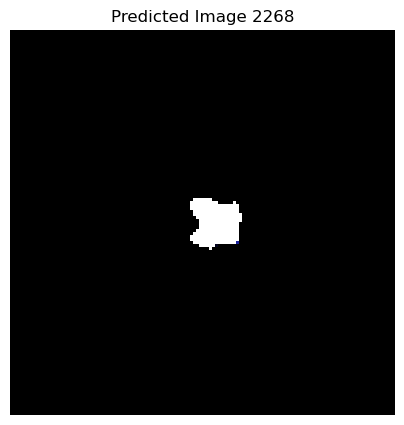

In [42]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

In [8]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import Conv2D, UpSampling2D, Input
from keras.models import Model
import keras.backend as K

# Function to load DeepLabV3+ with a specific input shape
def DeeplabV3Plus(input_shape=(128, 128, 3), num_classes=3):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    
    # Extract encoder features
    x = base_model.output  # (4x4)

    # Add ASPP (Atrous Spatial Pyramid Pooling)
    x = Conv2D(256, (1, 1), activation='relu', padding="same")(x)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (8x8)

    # Decoder: Upsample step by step
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (16x16)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (32x32)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (64x64)
    x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x)  # (128x128)

    # Final segmentation head
    outputs = Conv2D(num_classes, (1, 1), activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=outputs, name="DeepLabV3Plus")
    
    return model


In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model = DeeplabV3Plus()
#deeplab_model.summary()
#m#odel= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


In [119]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
early_stopping_dice = EarlyStopping(monitor="val_dice_coef", mode="max", patience=100, restore_best_weights=True)
early_stopping_iou = EarlyStopping(monitor="val_iou_coef", mode="max", patience=100, restore_best_weights=True)
results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300,callbacks=[early_stopping_dice, early_stopping_iou])

Epoch 1/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - dice_coef: 0.7542 - iou_coef: 0.6080 - loss: 0.2457 - precision: 0.7571 - recall: 0.7723 - val_dice_coef: 0.6480 - val_iou_coef: 0.4880 - val_loss: 0.3524 - val_precision: 0.7317 - val_recall: 0.6004
Epoch 2/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - dice_coef: 0.7589 - iou_coef: 0.6133 - loss: 0.2411 - precision: 0.7750 - recall: 0.7580 - val_dice_coef: 0.6498 - val_iou_coef: 0.4916 - val_loss: 0.3506 - val_precision: 0.7218 - val_recall: 0.6123
Epoch 3/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - dice_coef: 0.7612 - iou_coef: 0.6163 - loss: 0.2388 - precision: 0.7645 - recall: 0.7731 - val_dice_coef: 0.6240 - val_iou_coef: 0.4647 - val_loss: 0.3764 - val_precision: 0.7767 - val_recall: 0.5475
Epoch 4/300
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - dice_coef: 0.7665 - iou_coef: 0.6232 - loss: 0.2335 - precision: 0.7822 - recall: 0.7650 - val_dice_coef: 0.6414 - val_iou_coef: 0.4818 - val_loss: 0.3593 - val_precision: 

In [69]:
predictions = model.predict(x_train)

377/377 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


In [120]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - dice_coef: 0.6317 - iou_coef: 0.4812 - loss: 0.3682 - precision: 0.6759 - recall: 0.6924
Test Metrics: [0.34559178352355957, 0.6540942192077637, 0.4980725944042206, 0.6735970377922058, 0.6980478167533875]


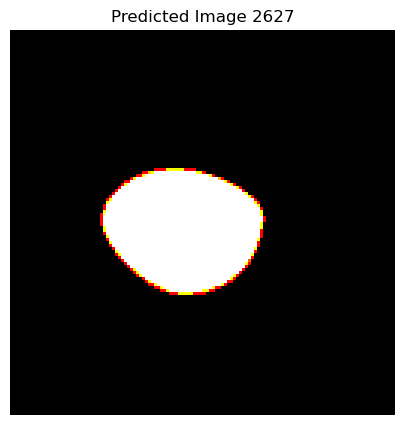

In [118]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

In [9]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, 
                          concatenate, Input, LeakyReLU, Add)
from keras.models import Model

Name = "Enhanced_MobileNetV2_U-NetPP"

# Function to create a residual convolutional block
def conv_block(inputs, num_filters, dropout_rate=0.2):
    shortcut = Conv2D(num_filters, (1, 1), padding="same")(inputs)  # Adjust channels
    shortcut = BatchNormalization()(shortcut)

    x = Conv2D(num_filters, (3, 3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Dropout(dropout_rate)(x)

    x = Conv2D(num_filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    # Residual Connection (Now Shapes Match)
    x = Add()([x, shortcut])  
    return x

# Build the enhanced UNet++
def enhanced_mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 feature extraction)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # **Atrous Convolution in bottleneck for better feature extraction**
    c5 = Conv2D(512, (3, 3), dilation_rate=2, padding="same", activation="relu")(c5)

    # **Decoder (UNet++ with increased filters and residual connections)**
    d4_1 = conv_block(c4, 512)
    d3_1 = conv_block(c3, 256)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 256)

    d2_1 = conv_block(c2, 128)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 128)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 128)

    d1_1 = conv_block(c1, 64)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 64)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 64)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 64)

    # **Final upsampling and output**
    u0_1 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 32, dropout_rate=0.1)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)

    model = Model(inputs=mobilenet.input, outputs=outputs, name="Enhanced_MobileNetV2_UNetPlusPlus")
    return model


In [10]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model = enhanced_mobilenet_unetpp()
#enhanced_unetpp_model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()



2025-03-08 19:39:30.985971: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
/home/gourib/mnt/sdb/conds_envs/newk/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [11]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
# early_stopping_dice = EarlyStopping(monitor="val_dice_coef", mode="max", patience=100, restore_best_weights=True)
# early_stopping_iou = EarlyStopping(monitor="val_iou_coef", mode="max", patience=100, restore_best_weights=True)
# results = model.fit(x_train,mask_train, validation_split=0.2, batch_size=32, epochs=300,callbacks=[early_stopping_dice, early_stopping_iou])

In [12]:
predictions = model.predict(x_train)
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)

I0000 00:00:1741442982.409880  634074 service.cc:146] XLA service 0x74e704002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741442982.409959  634074 service.cc:154]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-08 19:39:42.472800: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-08 19:39:42.896645: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90201


  5/377 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step

I0000 00:00:1741442986.850642  634074 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


377/377 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step


KeyboardInterrupt: 

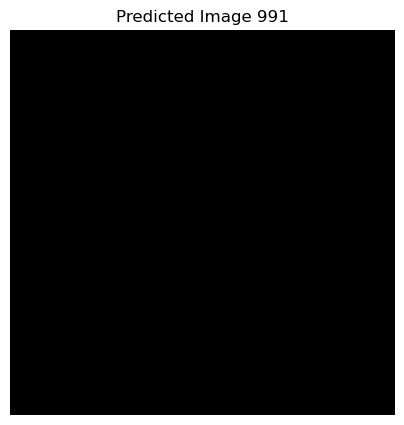

In [68]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

ValueError: Unrecognized keyword arguments passed to BatchNormalization: {'renorm': True}

In [4]:
import os
import numpy as np
from glob import glob
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

input_dir = "/home/gourib/LIDC-IDRI-slices"
img_shape = (128,128)  # Adjust according to your requirement
Thres = Thres = 5000/255

images = []
masks = []
y = []

# Step 1: Get all patient IDs
patients = sorted(os.listdir(input_dir))

# Step 2: Split patients into train and test sets
train_patients, test_patients = train_test_split(patients, train_size=0.8, random_state=25)

def load_patient_data(patient_list):
    """Load images and masks for the given list of patients"""
    images, masks, labels = [], [], []
    
    for patient in patient_list:
        patient_path = os.path.join(input_dir, patient)
        
        for nodule in os.listdir(patient_path):
            mask0, mask1, mask2, mask3 = [], [], [], []

            # Load images
            for filename in glob(f"{patient_path}/{nodule}/images/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                images.append(np.asarray(img))

            # Load masks
            for filename in glob(f"{patient_path}/{nodule}/mask-0/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask0.append(np.asarray(img))
            for filename in glob(f"{patient_path}/{nodule}/mask-1/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask1.append(np.asarray(img))
            for filename in glob(f"{patient_path}/{nodule}/mask-2/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask2.append(np.asarray(img))
            for filename in glob(f"{patient_path}/{nodule}/mask-3/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask3.append(np.asarray(img))

            # Determine final mask selection
            for i in range(len(mask0)):
                white_sum = np.array([mask0[i].sum(), mask1[i].sum(), mask2[i].sum(), mask3[i].sum()])
                cnt = sum(mask.sum() > Thres for mask in [mask0[i], mask1[i], mask2[i], mask3[i]])

                if cnt > 2:
                    labels.append(1)
                    masks.append([mask0[i], mask1[i], mask2[i], mask3[i]][white_sum.argmax()])
                else:
                    labels.append(0)
                    masks.append([mask0[i], mask1[i], mask2[i], mask3[i]][white_sum.argmin()])
    
    return images, masks, labels
    

# Step 3: Load training and testing data based on patient-wise split
x_train, mask_train, y_train = load_patient_data(train_patients)
x_test, mask_test, y_test = load_patient_data(test_patients)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train)/255, np.array(x_test)/255
mask_train, mask_test = np.array(mask_train)/255, np.array(mask_test)/255
y_train, y_test = np.array(y_train), np.array(y_test)

# Print shapes
print(x_train.shape, x_test.shape)
print(mask_train.shape, mask_test.shape)

(12376, 128, 128, 3) (3172, 128, 128, 3)
(12376, 128, 128, 3) (3172, 128, 128, 3)


In [13]:
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Value {u}: {c} occurrences")

Value 0: 6063 occurrences
Value 1: 5989 occurrences


In [14]:
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Value {u}: {c} occurrences")

Value 0: 1916 occurrences
Value 1: 1580 occurrences


In [5]:
import tensorflow as tf

# Download InceptionV3 weights
inception_weights_path = tf.keras.utils.get_file(
    'inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5',
    'https://storage.googleapis.com/tensorflow/keras-applications/inception_v3/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'
)

# Download VGG16 weights
vgg16_weights_path = tf.keras.utils.get_file(
    'vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5',
    'https://storage.googleapis.com/tensorflow/keras-applications/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
)

print("InceptionV3 weights saved at:", inception_weights_path)
print("VGG16 weights saved at:", vgg16_weights_path)


InceptionV3 weights saved at: /home/gourib/.keras/datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5
VGG16 weights saved at: /home/gourib/.keras/datasets/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5


In [6]:
import tensorflow as tf
from keras.applications import VGG16, InceptionV3
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate
from keras.models import Model
from keras.optimizers import Adam
vgg16_weights_path = "/home/gourib/.keras/datasets/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
inception_weights_path = "/home/gourib/.keras/datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5"
# Load pre-trained models with local weights
vgg16_base = VGG16(weights=vgg16_weights_path, include_top=False, input_shape=(128,128, 3))
inception_base = InceptionV3(weights=inception_weights_path, include_top=False, input_shape=(128,128, 3))

# Freezing 25% of layers in both models
for layer in vgg16_base.layers[:int(len(vgg16_base.layers) * 0.3)]:
    layer.trainable = False
for layer in inception_base.layers[:int(len(inception_base.layers) * 0.3)]:
    layer.trainable = False

# Combine outputs
vgg16_output = GlobalAveragePooling2D()(vgg16_base.output)
inception_output = GlobalAveragePooling2D()(inception_base.output)
combined_features = Concatenate()([vgg16_output, inception_output])
x = Dense(256, activation='relu')(combined_features)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

# Build and compile the ensemble model

2025-03-09 17:57:47.715129: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30346 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


dropout

In [22]:
import tensorflow as tf
from keras.applications import VGG16, InceptionV3
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate
from keras.models import Model
from keras.optimizers import Adam

vgg16_weights_path = "/home/gourib/.keras/datasets/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
inception_weights_path = "/home/gourib/.keras/datasets/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5"

# Load pre-trained models with local weights
vgg16_base = VGG16(weights=vgg16_weights_path, include_top=False, input_shape=(128,128, 3))
inception_base = InceptionV3(weights=inception_weights_path, include_top=False, input_shape=(128,128, 3))

# Freezing 25% of layers in both models
for layer in vgg16_base.layers[:int(len(vgg16_base.layers) * 0.25)]:
    layer.trainable = False
for layer in inception_base.layers[:int(len(inception_base.layers) * 0.25)]:
    layer.trainable = False

# Combine outputs
vgg16_output = GlobalAveragePooling2D()(vgg16_base.output)
vgg16_output = Dropout(0.3)(vgg16_output)  # 🔹 Dropout after VGG16 pooling

inception_output = GlobalAveragePooling2D()(inception_base.output)
inception_output = Dropout(0.3)(inception_output)  # 🔹 Dropout after Inception pooling

combined_features = Concatenate()([vgg16_output, inception_output])

x = Dense(256, activation='relu')(combined_features)
x = Dropout(0.5)(x)  # Existing dropout after Dense layer
x = Dense(128, activation='relu')(x)  # 🔹 Additional dense layer
x = Dropout(0.3)(x)  # 🔹 Extra dropout to further regularize

output = Dense(1, activation='sigmoid')(x)

# Build the ensemble model
ensemble_model = Model(inputs=[vgg16_base.input, inception_base.input], outputs=output)

# Compile the model
ensemble_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='binary_crossentropy',
                       metrics=['acc'])



In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import Recall, Precision, AUC, TruePositives, TrueNegatives, FalseNegatives, FalsePositives

ensemble_model = Model(inputs=[vgg16_base.input, inception_base.input], outputs=output)

from keras.callbacks import EarlyStopping
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
# keras.optimizers.Adam()
ensemble_model.compile (optimizer=optimizer ,  loss=keras.losses.BinaryCrossentropy() , 
               metrics=['acc',Recall(),Precision(),AUC(),TruePositives(),TrueNegatives(),FalseNegatives(),FalsePositives()])
early_stopping = EarlyStopping(
    monitor='val_acc', 
    patience=15, 
    min_delta=0.001, 
    mode='max',
    restore_best_weights=True
)


In [8]:
history = ensemble_model.fit([x_train,x_train], y_train, epochs=100, validation_split=0.2,
                    batch_size=64,callbacks=[early_stopping])

Epoch 1/100


I0000 00:00:1741523300.390930  735244 service.cc:146] XLA service 0x78e4c80809c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741523300.391618  735244 service.cc:154]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-09 17:58:21.357398: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-09 17:58:23.869354: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90201
I0000 00:00:1741523336.441208  735244 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/155 ━━━━━━━━━━━━━━━━━━━━ 123s 453ms/step - acc: 0.5372 - auc: 0.5598 - false_negatives: 1115.8462 - false_positives: 1104.4231 - loss: 0.7140 - precision: 0.5369 - recall: 0.5466 - true_negatives: 1418.2244 - true_positives: 1384.8397 - val_acc: 0.5246 - val_auc: 0.6717 - val_false_negatives: 186.0000 - val_false_positives: 991.0000 - val_loss: 0.7550 - val_precision: 0.4803 - val_recall: 0.8312 - val_true_negatives: 383.0000 - val_true_positives: 916.0000
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - acc: 0.7771 - auc: 0.8462 - false_negatives: 755.0449 - false_positives: 350.5833 - loss: 0.4755 - precision: 0.8374 - recall: 0.6885 - true_negatives: 2171.8845 - true_positives: 1745.8206 - val_acc: 0.6721 - val_auc: 0.6975 - val_false_negatives: 493.0000 - val_false_positives: 319.0000 - val_loss: 0.7162 - val_precision: 0.6562 - val_recall: 0.5526 - val_true_negatives: 1055.0000 - val_true_positives: 609.0000
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - ac

In [9]:
test_results = ensemble_model.evaluate([x_test, x_test], y_test, batch_size=64)
print("Test Metrics:", test_results)


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - acc: 0.7110 - auc: 0.7744 - false_negatives: 247.0980 - false_positives: 253.3529 - loss: 1.6081 - precision: 0.7133 - recall: 0.7107 - true_negatives: 587.8039 - true_positives: 573.3922
Test Metrics: [1.7916054725646973, 0.690416157245636, 0.6848793029785156, 0.689258337020874, 0.7468769550323486, 1078.0, 1112.0, 496.0, 486.0]


In [6]:
import numpy as np

# Save in the current directory
np.savez_compressed("lung_nodule_data.npz", x_train=x_train, x_test=x_test, y_train=y_train, y_test=y_test)

print("Compressed dataset saved successfully!")


Compressed dataset saved successfully!
